In [1]:
# Test is connected
print("CamGuard")

CamGuard


download needed lib

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.2 MB/s eta 0:00:00


import needed lib

In [3]:
import os
import zipfile
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


loading dataset from drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive"
os.listdir(path)

['Colab Notebooks',
 'Smart Surviellance & Safety System.pptx',
 'Me',
 'weapon_dataset.zip']

In [6]:
path_dataset_zip = "/content/drive/MyDrive/weapon_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(path_dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


### Dataset Information

The `data.yaml` file is critical for YOLOv8 training as it defines the paths to your training, validation, and test images, the number of classes, and their names. Let's inspect its contents to understand the dataset's structure.

In [11]:
import yaml

def get_dataset_info(yaml_path):
    with open(yaml_path, 'r') as file:
        data = yaml.safe_load(file)
    print("Dataset Configuration (data.yaml):")
    for key, value in data.items():
        print(f"  {key}: {value}")
    return data

data_yaml_path = "/content/dataset/weapon_dataset/data.yaml"

dataset_info = get_dataset_info(data_yaml_path)

Dataset Configuration (data.yaml):
  train: /content/dataset/weapon_dataset/train
  val: /content/dataset/weapon_dataset/valid
  test: /content/dataset/weapon_dataset/test
  nc: 1
  names: ['weapon']


In [12]:
import os

def count_images_in_dataset(dataset_info):
    for key in ['train', 'val', 'test']:
        path = dataset_info[key]
        path = os.path.join(path, 'labels')
        num_images = len([name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))])
        print(f"Number of images in {key} set: {num_images}")

count_images_in_dataset(dataset_info)

Number of images in train set: 7494
Number of images in val set: 1933
Number of images in test set: 922


In [13]:
class YOLOv8WeaponDetector:
    def __init__(self, model_size="yolov8n.pt", device=None):
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = YOLO(model_size)
        self.model.to(self.device)

    def train(self, data_yaml, epochs=50, imgsz=640, batch=16):
        results = self.model.train(
            data=data_yaml,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            device=self.device,
            name="weapon_detector"
        )
        return results

    def validate(self):
        return self.model.val()

    def predict(self, image_path, conf=0.25):
        results = self.model.predict(source=image_path, conf=conf)
        return results

    def export(self, format="onnx"):
        self.model.export(format=format)

In [15]:
detector_n = YOLOv8WeaponDetector(model_size="yolov8n.pt")

### Train YOLOv8n (nano) model

In [ ]:
data_yaml_path = "/content/dataset/weapon_dataset/data.yaml"

print("Training YOLOv8n model...")
results_n = detector_n.train(data_yaml=data_yaml_path, epochs=100, imgsz=620, batch=32)
print("YOLOv8n training complete.")

Training YOLOv8n model...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/weapon_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=620, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detector, nbs=64, nms=False, opset=None, optimize=False, op

YOLOv8n Training Results:


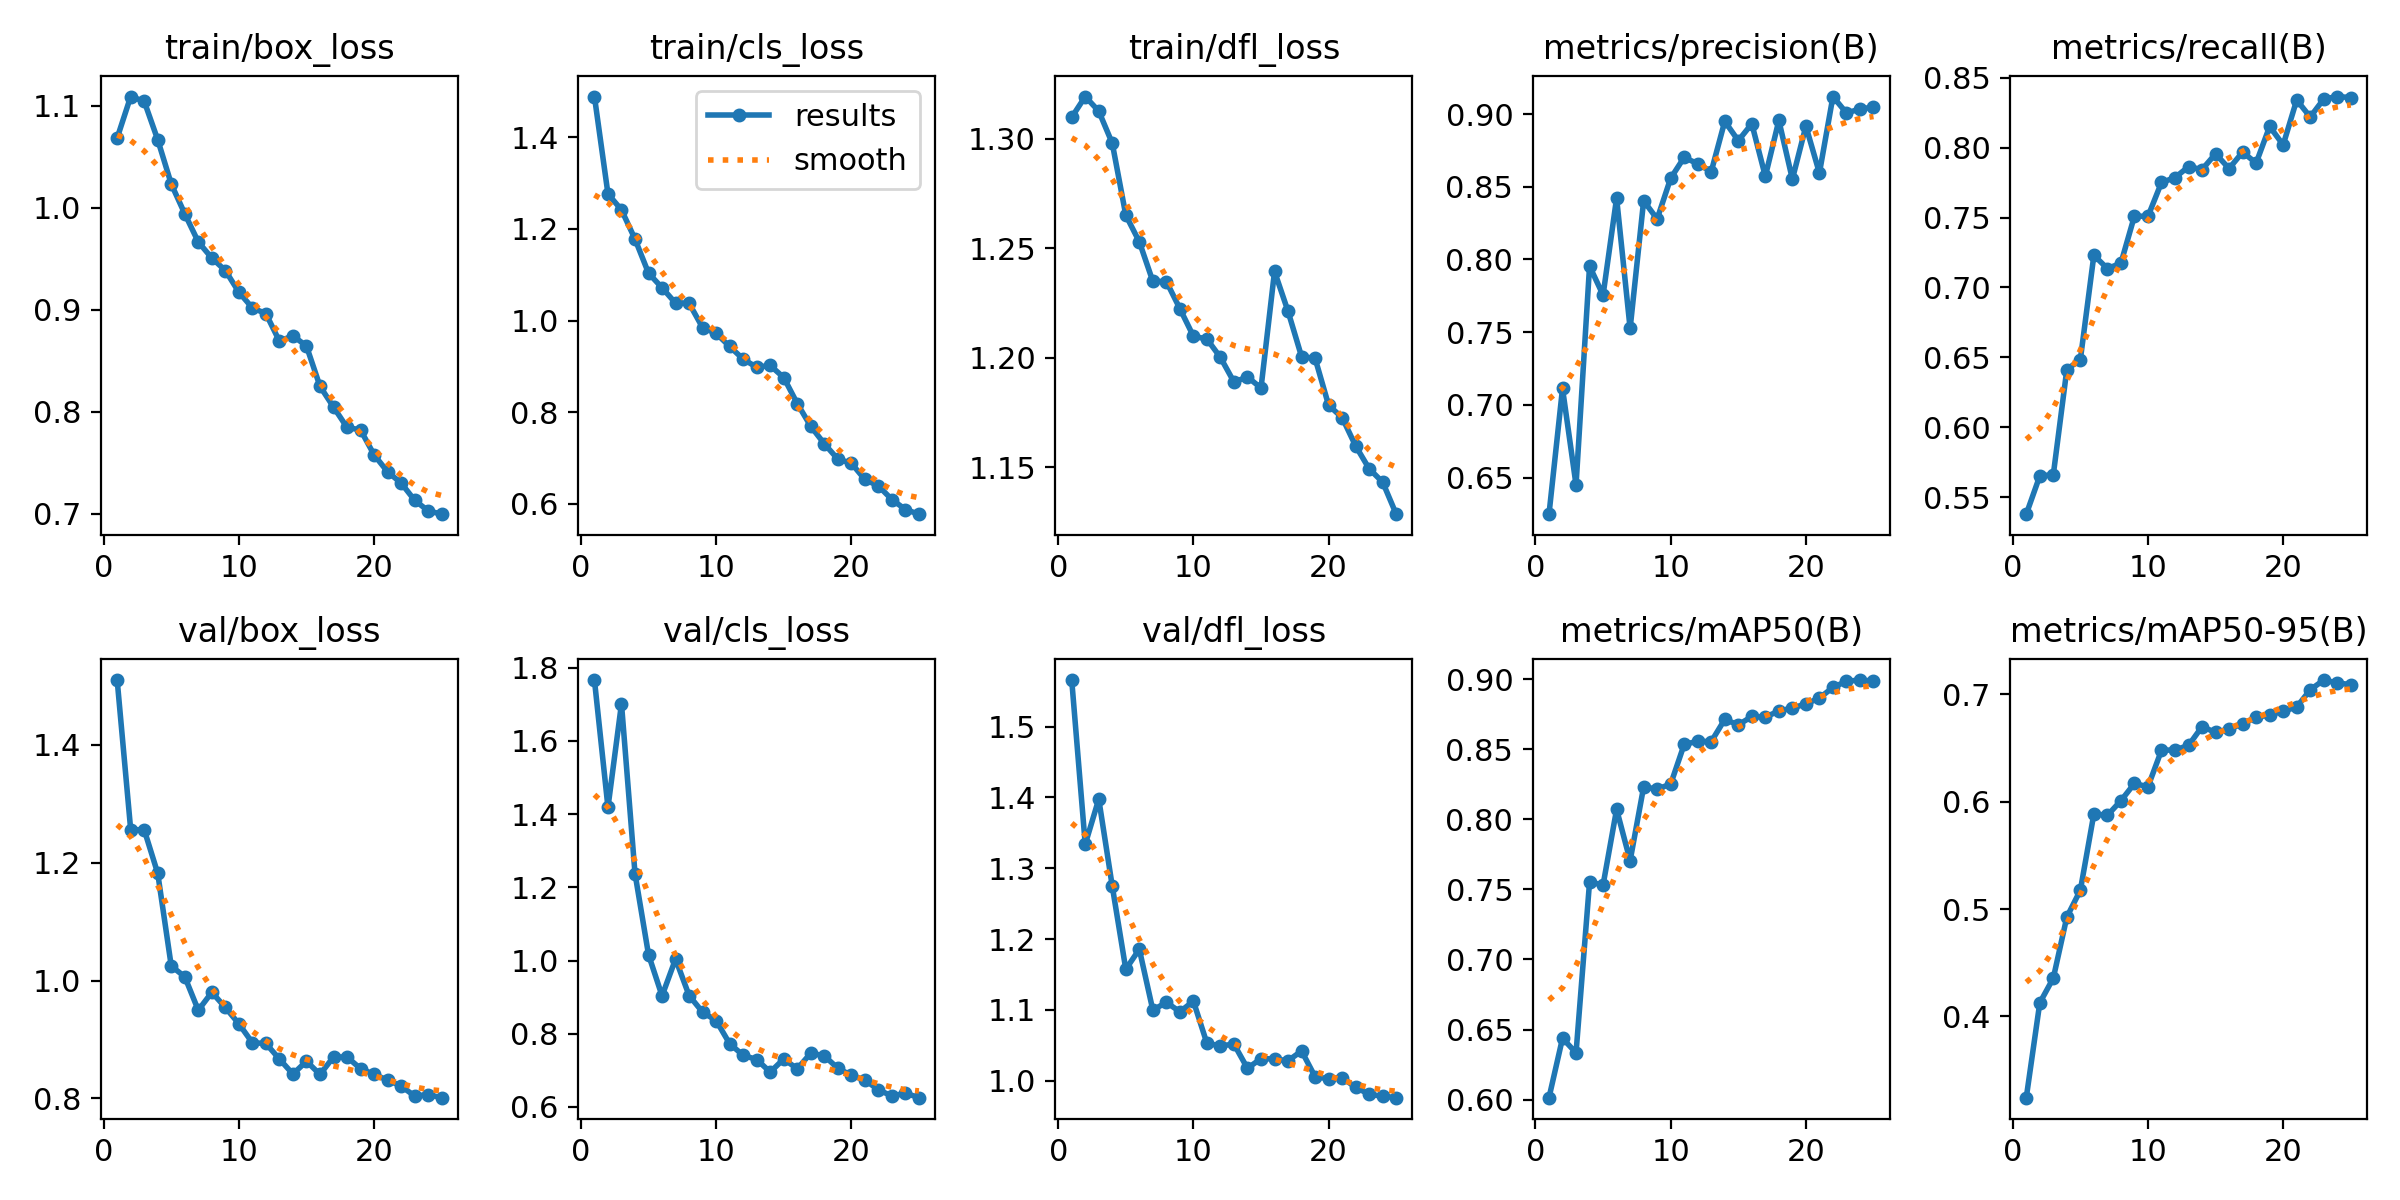

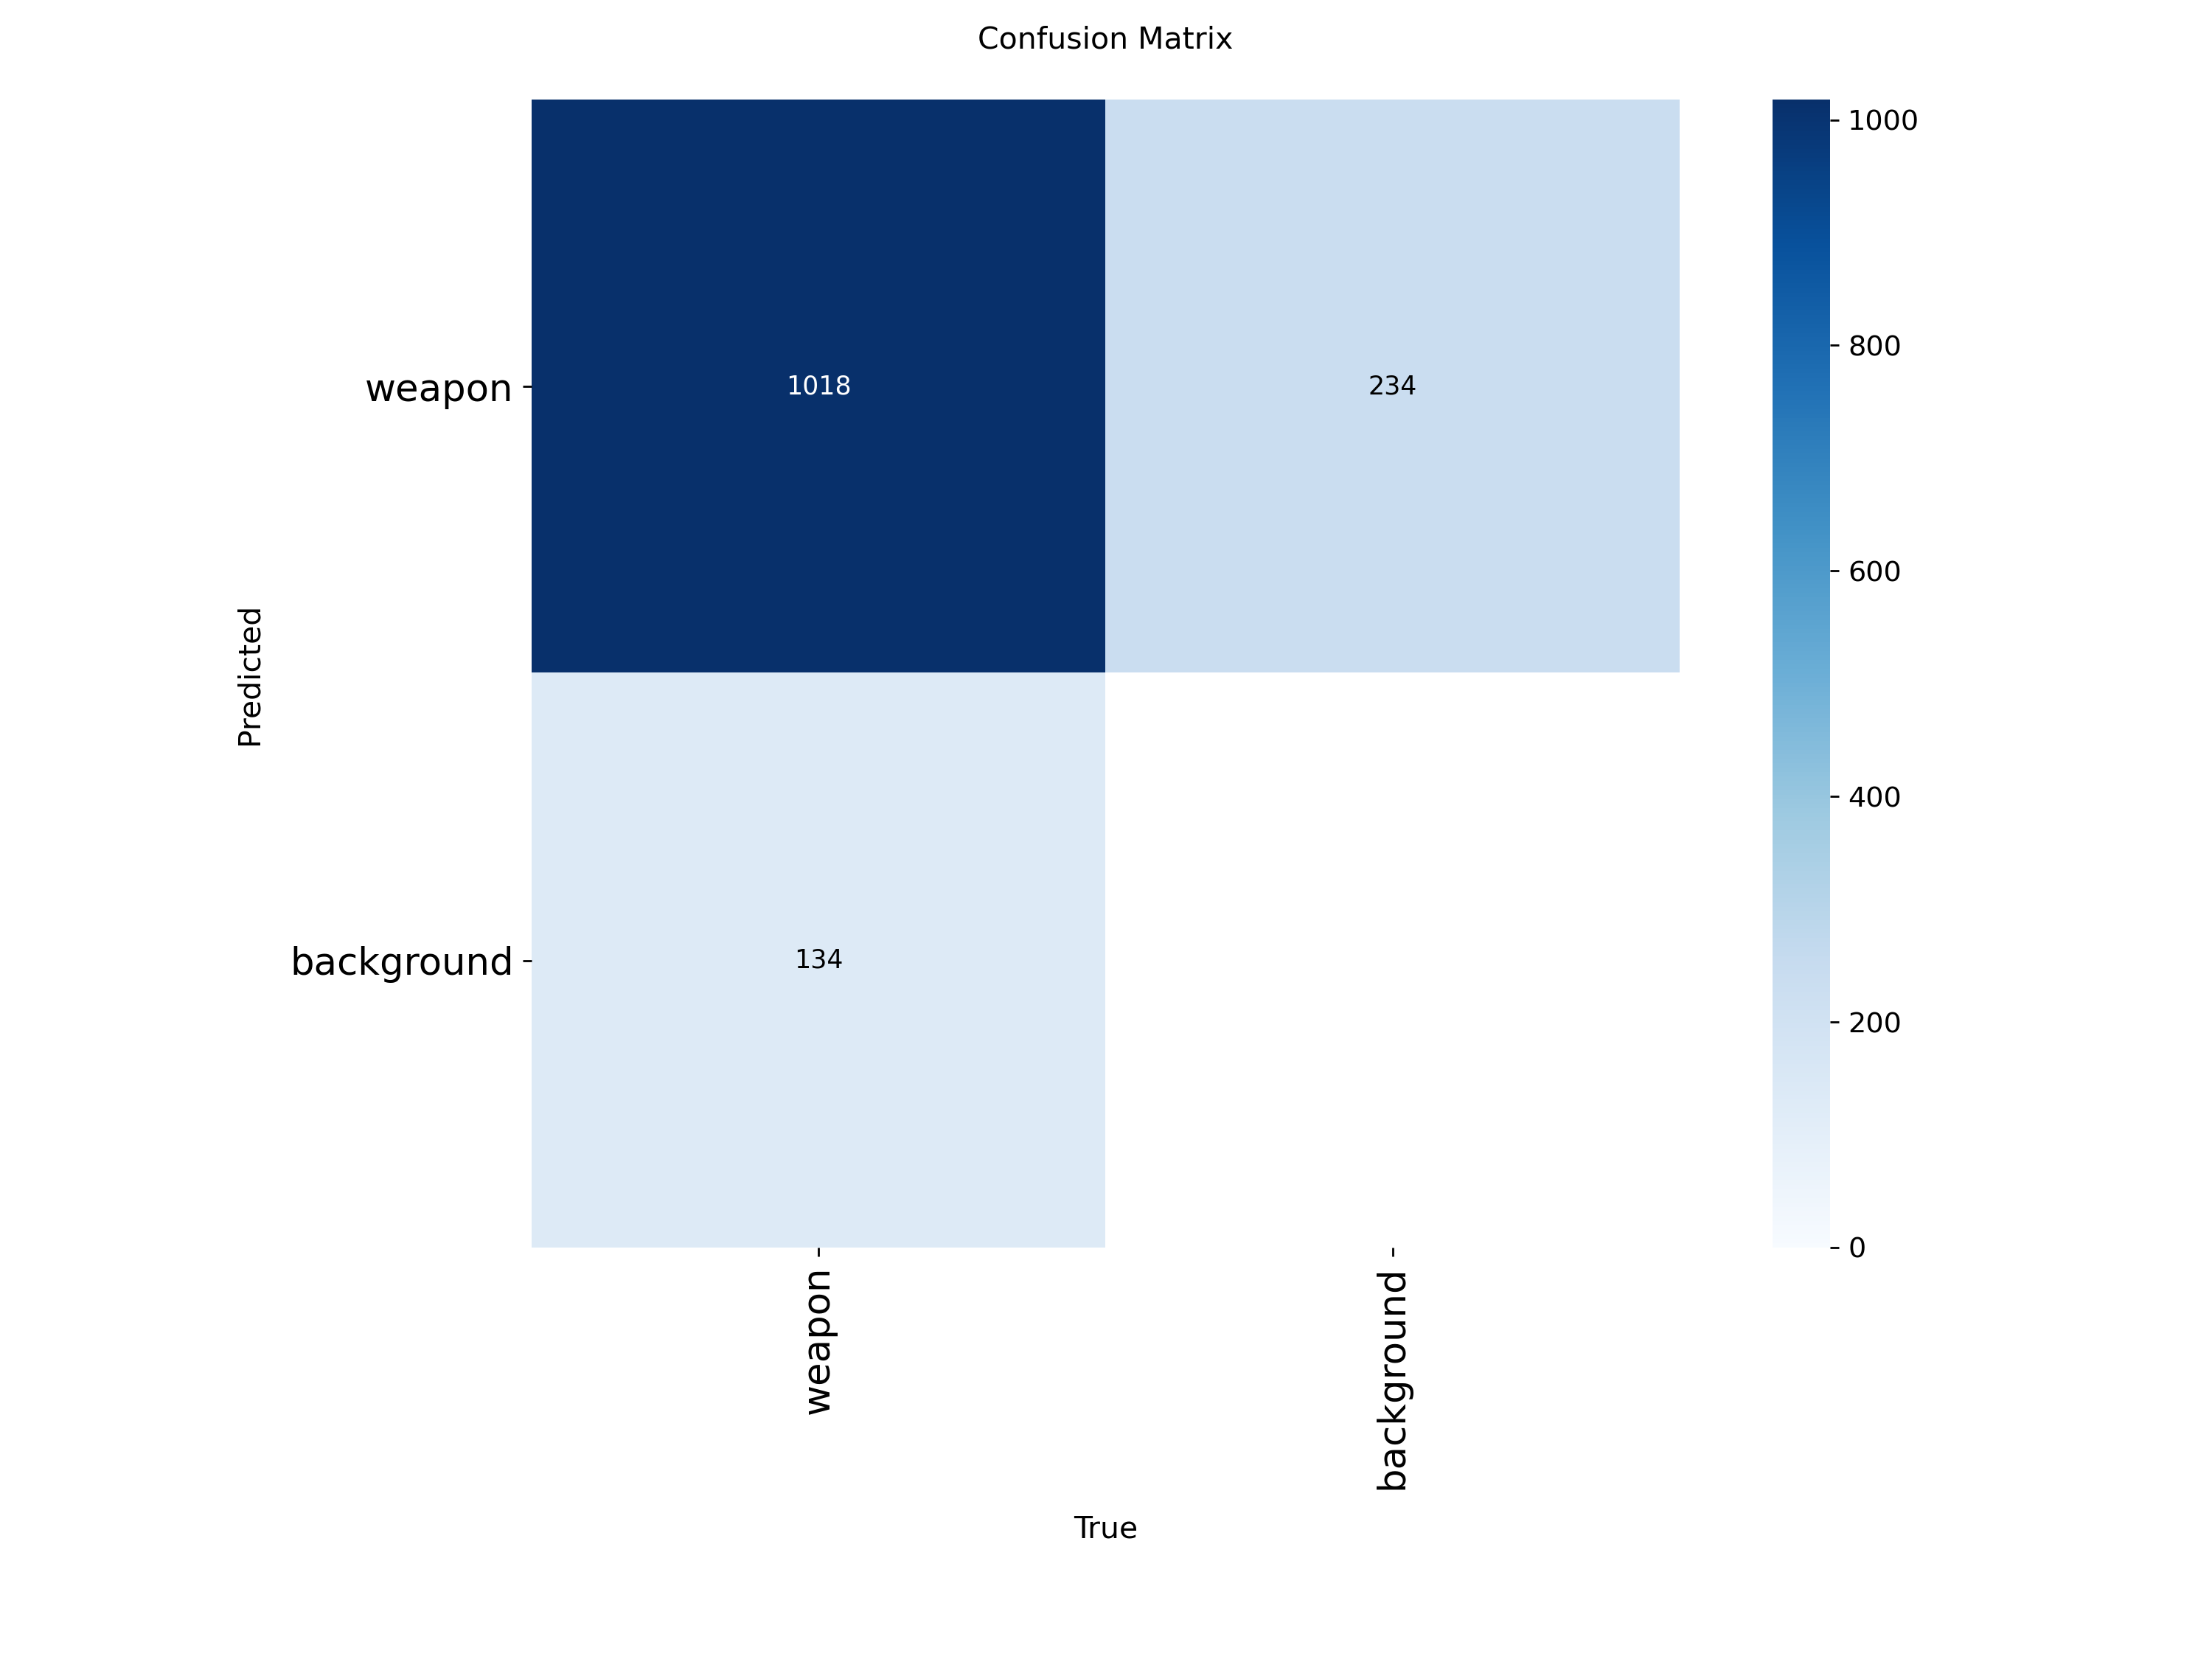

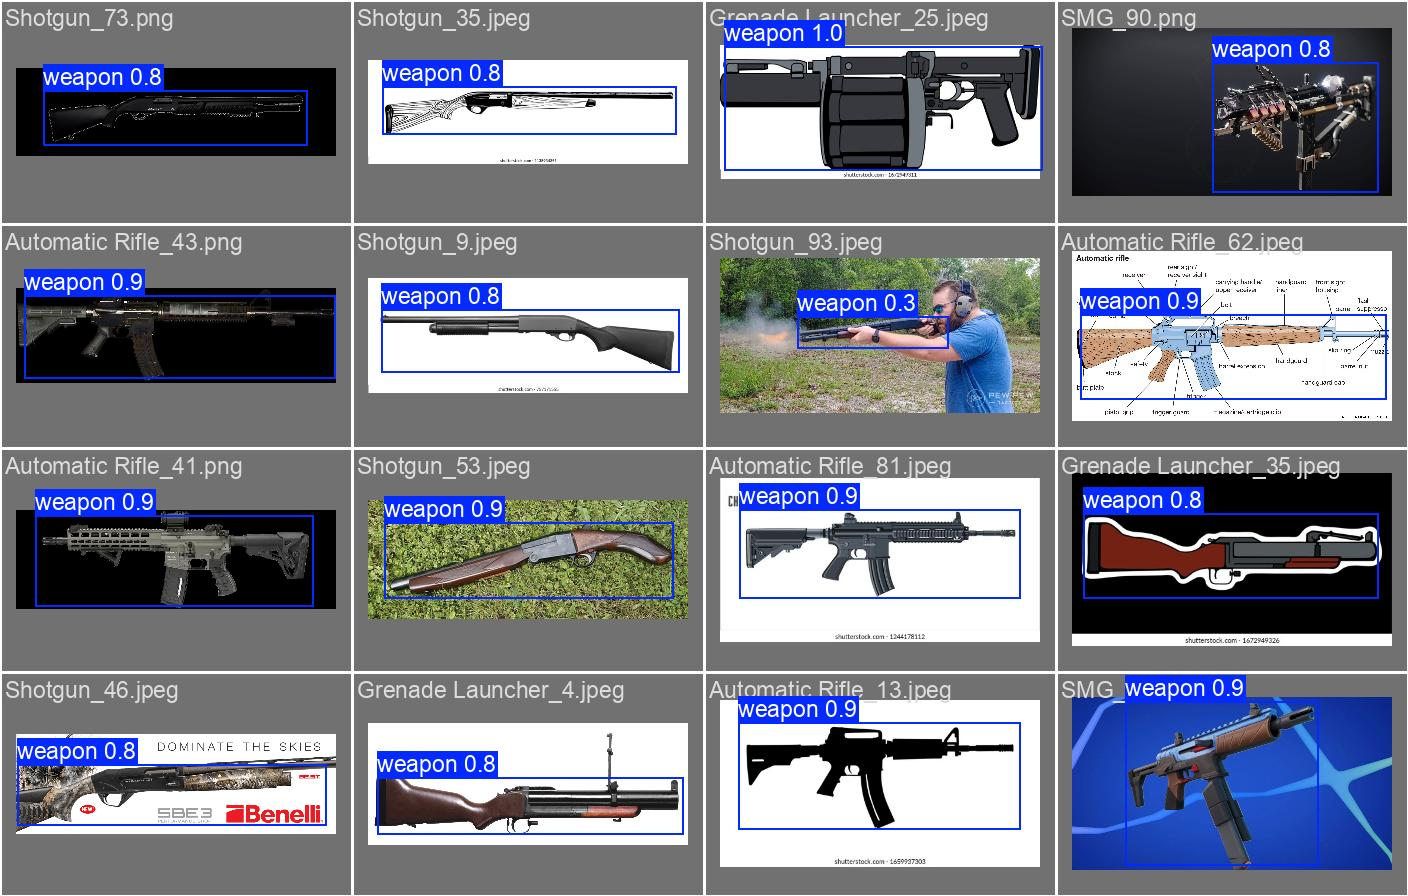

In [ ]:
from IPython.display import Image, display

print("YOLOv8n Training Results:")
display(Image(filename=os.path.join(results_n.save_dir, 'results.png')))
display(Image(filename=os.path.join(results_n.save_dir, 'confusion_matrix.png')))
display(Image(filename=os.path.join(results_n.save_dir, 'val_batch0_pred.jpg')))

In [ ]:
print("Exporting YOLOv8n model...")
detector_n.export(format="onnx")
print("YOLOv8n model exported.")
from google.colab import files

files.download(os.path.join(results_n.save_dir, 'weights', 'best.onnx'))


Exporting YOLOv8n model...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/weapon_detector/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 0.9s, saved as '/content/runs/detect/weapon_detector/weights/best.onnx' (11.6 MB)

Export complete (1.1s)
Results saved to /content/runs/detect/weapon_detector/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/weapon_detector/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/weapon_detector/weights/best.onnx imgsz=320 data=/content/dataset/weapon_dataset/data.yaml  
Visualize:       https://netron.app
YOLOv8n model exported.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os

image_files = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']

# Download YOLOv8n result images
print("Downloading YOLOv8n result images...")
for img_file in image_files:
    file_path = os.path.join(results_n.save_dir, img_file)
    if os.path.exists(file_path):
        files.download(file_path)
    else:
        print(f"Warning: {img_file} not found for YOLOv8n at {file_path}")


NameError: name 'results_n' is not defined